In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import time

import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from train_utils import evaluate, make_model, snapshot, steps_per_epoch, train_one_epoch, update_norm

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device)

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_ds = datasets.MNIST("data", train=True, download=True, transform=transform)
test_ds = datasets.MNIST("data", train=False, download=True, transform=transform)
test_loader = DataLoader(test_ds, batch_size=1000, shuffle=False)
print("train:", len(train_ds), "test:", len(test_ds))

torch.manual_seed(42)

device: mps
train: 60000 test: 10000


## Прогноз (до запуска)

Что изменится при переходе с batch 32 на batch 128 при том же lr = 1e-3 — по времени эпохи, числу шагов и accuracy после 1 эпохи?

Мой ответ:
- Временя эпохи увеличится примерно в 2 раза
- Число шагов сократится в 4 раза (так как батч увеличили в 4 раза)
- Так как lr не увеличили (а его должны увеличивать примерно в $\sqrt{4}$ раза, то есть в нашем примере ~ в 2 раза), то accuracy будет хуже, чем при batch=32

## Эксперимент A — batch 32 vs 128

Adam, lr = 1e-3, одна эпоха, одинаковый seed, новая модель для каждого прогона.
Таблица: шаги за эпоху (сверить со `steps_per_epoch`), время эпохи (`time.perf_counter`), test accuracy.

In [5]:
for bsize in [32, 128]:
    torch.manual_seed(42)
    model = make_model()
    model = model.to(device)
    train_loader = DataLoader(train_ds, batch_size=bsize, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()
    start = time.perf_counter()
    losses, norms = train_one_epoch(model=model, loader=train_loader, optimizer=optimizer, loss_fn=loss_fn, device=device)
    end = time.perf_counter()
    steps=len(losses)
    acc = evaluate(model=model, loader=test_loader, device=device)
    print(f"bs: {bsize}, time: {end - start:.2f}, acc: {acc:.4f}")
    print(f"ожидаемые шаги: {steps_per_epoch(n_samples=len(train_ds), batch_size=bsize)}, реальные шаги: {steps}")


bs: 32, time: 10.32, acc: 0.9630
ожидаемые шаги: 1875, реальные шаги: 1875
bs: 128, time: 4.70, acc: 0.9542
ожидаемые шаги: 469, реальные шаги: 469


## Эксперимент B (по желанию) — batch 128, lr = 4e-3

Получится ли вернуть качество batch 32 за одну эпоху?

In [6]:
for bsize in [32, 128]:
    torch.manual_seed(42)
    model = make_model()
    model = model.to(device)
    train_loader = DataLoader(train_ds, batch_size=bsize, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=4e-3)
    loss_fn = nn.CrossEntropyLoss()
    start = time.perf_counter()
    losses, norms = train_one_epoch(model=model, loader=train_loader, optimizer=optimizer, loss_fn=loss_fn, device=device)
    end = time.perf_counter()
    steps=len(losses)
    acc = evaluate(model=model, loader=test_loader, device=device)
    print(f"bs: {bsize}, time: {end - start:.2f}, acc: {acc:.4f}")
    print(f"ожидаемые шаги: {steps_per_epoch(n_samples=len(train_ds), batch_size=bsize)}, реальные шаги: {steps}")


bs: 32, time: 10.13, acc: 0.9545
ожидаемые шаги: 1875, реальные шаги: 1875
bs: 128, time: 4.83, acc: 0.9630
ожидаемые шаги: 469, реальные шаги: 469


## Эксперимент C — Adam с постоянным lr vs Adam + scheduler

Batch 128, 3 эпохи, lr = 1e-3. Второй прогон — с `CosineAnnealingLR(T_max = общее число шагов за 3 эпохи)`.

Графики по шагам:
1. loss обоих прогонов;
2. `update_norms` обоих прогонов (ось y в log-масштабе).

Вопрос: уменьшается ли сдвиг весов к концу обучения у Adam без scheduler?

In [7]:
from torch.optim.lr_scheduler import CosineAnnealingLR

bsize, lr, n_epochs = 128, 1e-3, 3
n_steps = steps_per_epoch(len(train_ds), bsize)
results = {}

for mode in ["const lr", "cosine"]:
    torch.manual_seed(42)
    model = make_model().to(device)
    train_loader = DataLoader(train_ds, batch_size=bsize, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    # T_max — все шаги за 3 эпохи: lr плавно уходит от 1e-3 к 0 ровно к концу обучения
    scheduler = CosineAnnealingLR(optimizer, T_max=n_steps * n_epochs) if mode == "cosine" else None

    all_losses, all_norms = [], []
    for ep in range(n_epochs):
        losses, norms = train_one_epoch(model, train_loader, optimizer, loss_fn, device, scheduler=scheduler)
        all_losses.extend(losses)
        all_norms.extend(norms)
        acc = evaluate(model, test_loader, device)
        print(f"{mode:>8} | epoch {ep + 1}: acc {acc:.4f}, lr {optimizer.param_groups[0]['lr']:.2e}")

    results[mode] = (all_losses, all_norms)

const lr | epoch 1: acc 0.9542, lr 1.00e-03
const lr | epoch 2: acc 0.9669, lr 1.00e-03
const lr | epoch 3: acc 0.9703, lr 1.00e-03
  cosine | epoch 1: acc 0.9507, lr 7.50e-04
  cosine | epoch 2: acc 0.9649, lr 2.50e-04
  cosine | epoch 3: acc 0.9675, lr 0.00e+00


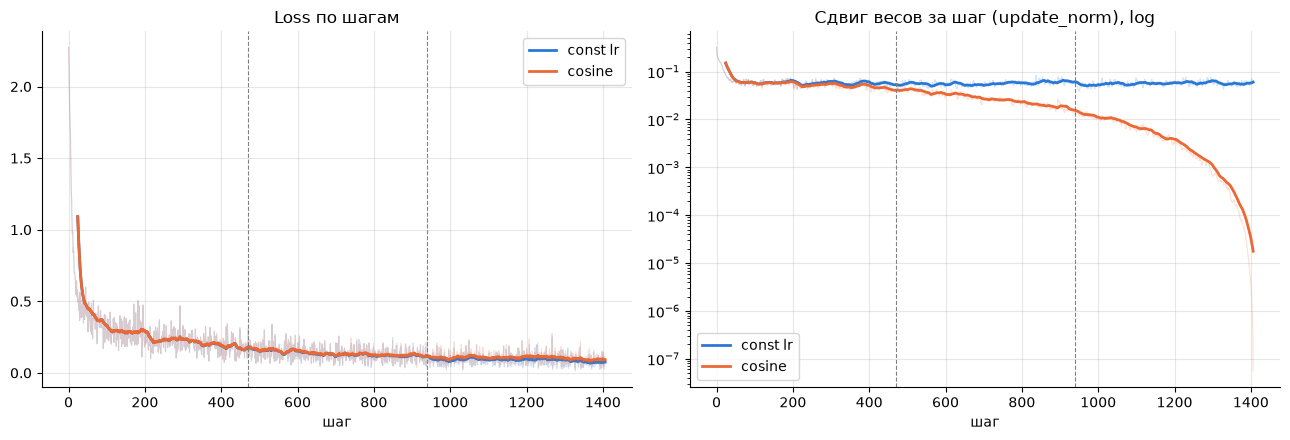

In [8]:
# Ожидает из ячейки выше:
# results = {"const lr": (losses, norms), "cosine": (losses, norms)} — списки по всем шагам за 3 эпохи
# n_steps = число шагов за одну эпоху (для разметки границ эпох)

COLORS = {"const lr": "#2a78d6", "cosine": "#eb6834"}


def smooth(values, k=25):
    # скользящее среднее: сырые значения по шагам слишком шумные
    kernel = torch.ones(k) / k
    return torch.conv1d(torch.tensor(values).view(1, 1, -1), kernel.view(1, 1, -1)).flatten()


fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
titles = ["Loss по шагам", "Сдвиг весов за шаг (update_norm), log"]

for ax, idx, title in zip(axes, [0, 1], titles):
    for name, run in results.items():
        values = run[idx]
        ax.plot(values, color=COLORS[name], alpha=0.2, linewidth=0.8)
        sm = smooth(values)
        ax.plot(range(len(values) - len(sm), len(values)), sm, color=COLORS[name], linewidth=2, label=name)
    for ep in range(1, len(values) // n_steps):
        ax.axvline(ep * n_steps, color="gray", linestyle="--", linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel("шаг")
    ax.grid(alpha=0.3)
    ax.legend()

axes[1].set_yscale("log")
for side in ("top", "right"):
    for ax in axes:
        ax.spines[side].set_visible(False)
plt.tight_layout()
plt.show()

## Выводы

1. *Вычислительные плюсы mini-batch:* GPU считает батч параллельно, поэтому шаг с batch 128 дороже шага с 32 не в 4, а примерно в 1.8 раза, а накладные расходы на шаг (step, zero_grad, snapshot) от батча не зависят — шагов в 4 раза меньше, эпоха быстрее в ~2.2 раза (10.3 с → 4.7 с).
2. *Батч ×4 при том же lr:* шагов за эпоху в 4 раза меньше (1875 → 469) при том же размере шага, поэтому модель за эпоху продвигается меньше и accuracy хуже (0.963 → 0.954); с lr ×4 (4e-3) качество вернулось (0.963), а batch 32 с таким lr наоборот просел — градиент по маленькому батчу шумнее.
3. *Adam и scheduler:* шаг Adam ≈ lr · m / √v, при уменьшении градиента m и √v уменьшаются вместе, поэтому размер шага задаёт lr, а не градиент — без scheduler сдвиг весов стоит на плато (~5·10⁻²) до конца, с cosine падает до ~10⁻⁵; на 3 эпохах accuracy с cosine чуть ниже (0.9675 vs 0.9703), т.к. lr режется рано, пока модель ещё далеко от минимума.